In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

%matplotlib inline

# Load Groundcover by Row dataset
data_path = Path("data/raw") / "Groundcover by Row.xlsx"
print(f"Reading data from: {data_path.resolve()}")

# Read full dataset, then filter to AREA == 1 only
df = pd.read_excel(data_path)
print("Original shape:", df.shape)

df = df[df["AREA"] == 1].copy()
print("Filtered to AREA == 1, shape:", df.shape)

df.head()

Reading data from: C:\Users\nhphuong\Desktop\Solar\all_data\data\raw\Groundcover by Row.xlsx
Original shape: (2160, 10)
Filtered to AREA == 1, shape: (1440, 10)


,YEAR,MONTH,DAY,TIME,AREA,TREATMENT,EU,ROW,COVER_TYPE,PERCENT_AREA
0,2025,5,21,13:06:00,1,strawberry,1,1.0,vegetation,0.021735
1,2025,5,21,13:06:00,1,strawberry,1,1.0,soil,0.036673
2,2025,5,21,13:06:00,1,strawberry,1,1.0,mulch,0.764893
3,2025,5,21,13:06:00,1,strawberry,1,1.0,black_plastic,0.000000
4,2025,5,21,13:06:00,1,strawberry,1,1.0,white_plastic,0.174010


In [3]:
# Save filtered AREA == 1 data to CSV in the project root
output_csv_path = "groundcover_area1.csv"
print(f"Saving filtered data to: {output_csv_path}")

df.to_csv(output_csv_path, index=False)

print("Done.")

Saving filtered data to: groundcover_area1.csv
Done.


In [4]:
# Number of distinct datetime (YEAR, MONTH, DAY, TIME) combinations
n_distinct = df[["YEAR", "MONTH", "DAY", "TIME"]].drop_duplicates().shape[0]
print(f"Distinct datetime combinations: {n_distinct}")

Distinct datetime combinations: 6


In [9]:
# Basic data overview and missing values

# Random sample for a quick look
display(df.sample(min(5, len(df)), random_state=0))

print("\nData types:")
dtypes = df.dtypes.to_frame("dtype")
display(dtypes)

print("\nMissing values per column:")
missing = df.isna().sum().sort_values(ascending=False).to_frame("n_missing")
missing["missing_ratio"] = missing["n_missing"] / len(df)
display(missing)

print("\nBasic numeric summary:")
num_summary = df.describe().T
display(num_summary)

,YEAR,MONTH,DAY,TIME,AREA,TREATMENT,EU,ROW,COVER_TYPE,PERCENT_AREA
34,2025,5,21,13:06:00,1,poll_one,4,1.0,white_plastic,0.000000
1541,2025,9,15,12:57:00,1,strawberry,11,1.0,soil,0.005422
1856,2025,10,16,NaN,1,squash,6,3.0,soil,0.136138
453,2025,6,18,12:08:00,1,squash,10,1.0,black_plastic,0.540000
141,2025,5,21,13:06:00,1,grass,15,1.0,soil,0.361025



Data types:


,dtype
YEAR,int64
MONTH,int64
DAY,int64
TIME,object
AREA,int64
TREATMENT,object
EU,int64
ROW,float64
COVER_TYPE,object
PERCENT_AREA,float64



Missing values per column:


,n_missing,missing_ratio
TIME,240,0.166667
YEAR,0,0.000000
MONTH,0,0.000000
DAY,0,0.000000
AREA,0,0.000000
TREATMENT,0,0.000000
EU,0,0.000000
ROW,0,0.000000
COVER_TYPE,0,0.000000
PERCENT_AREA,0,0.000000



Basic numeric summary:


,count,mean,std,min,25%,50%,75%,max
YEAR,1440.0,2025.000000,0.000000,2025.0,2025.00,2025.000000,2025.000000,2025.000000
MONTH,1440.0,7.500000,1.708418,5.0,6.00,7.500000,9.000000,10.000000
DAY,1440.0,17.666667,2.211851,15.0,16.00,17.000000,20.000000,21.000000
AREA,1440.0,1.000000,0.000000,1.0,1.00,1.000000,1.000000,1.000000
EU,1440.0,12.500000,6.924591,1.0,6.75,12.500000,18.250000,24.000000
ROW,1440.0,2.000000,1.000347,1.0,1.00,2.000000,3.000000,3.000000
PERCENT_AREA,1440.0,0.198752,0.277340,0.0,0.00,0.044415,0.324118,0.995736


In [10]:
# Overview of non-numeric (typically categorical) columns

non_numeric_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
print("Non-numeric columns:", non_numeric_cols)

for col in non_numeric_cols:
    print(f"\nColumn: {col}")
    vc = df[col].value_counts(dropna=False)
    summary = vc.to_frame("count")
    summary["frequency"] = summary["count"] / len(df)
    display(summary.head(20))

Non-numeric columns: ['TIME', 'TREATMENT', 'COVER_TYPE']

Column: TIME


,count,frequency
TIME,,
13:06:00,240,0.166667
12:08:00,240,0.166667
11:03:00,240,0.166667
13:11:00,240,0.166667
12:57:00,240,0.166667
NaN,240,0.166667



Column: TREATMENT


,count,frequency
TREATMENT,,
strawberry,180,0.125
broccoli,180,0.125
pepper,180,0.125
poll_one,180,0.125
grass,180,0.125
squash,180,0.125
poll_two,180,0.125
raspberry,180,0.125



Column: COVER_TYPE


,count,frequency
COVER_TYPE,,
vegetation,288,0.2
soil,288,0.2
mulch,288,0.2
black_plastic,288,0.2
white_plastic,288,0.2


Numeric columns: ['YEAR', 'MONTH', 'DAY', 'AREA', 'EU', 'ROW', 'PERCENT_AREA']


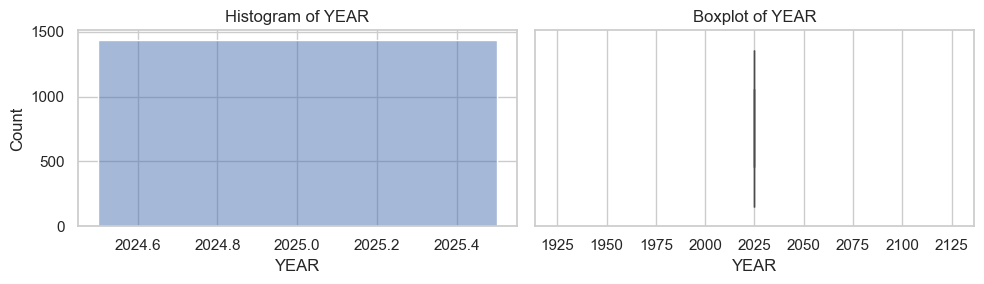

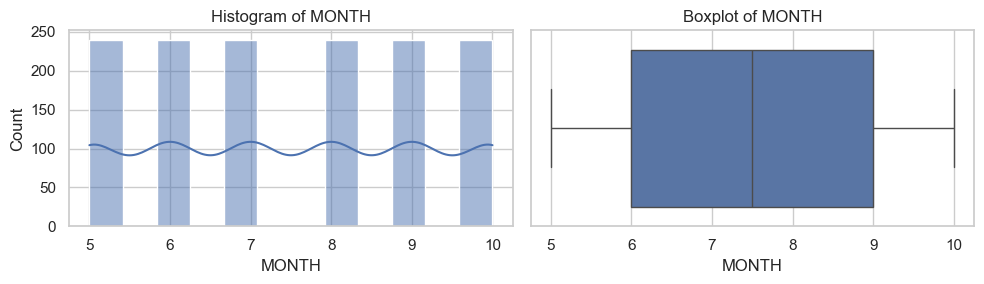

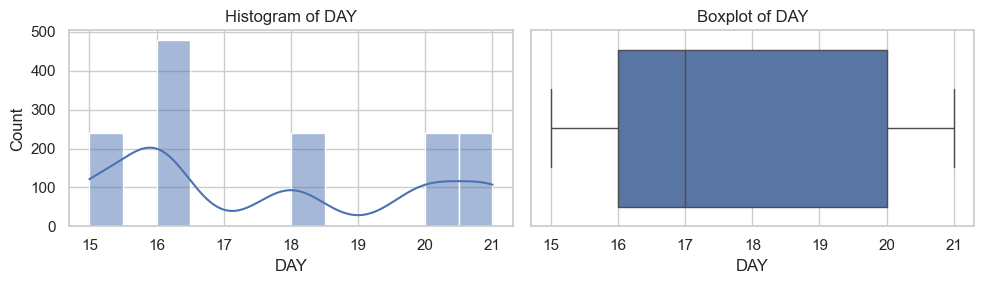

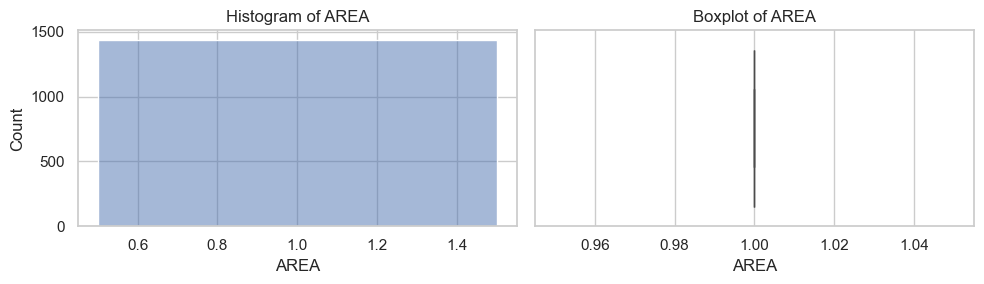

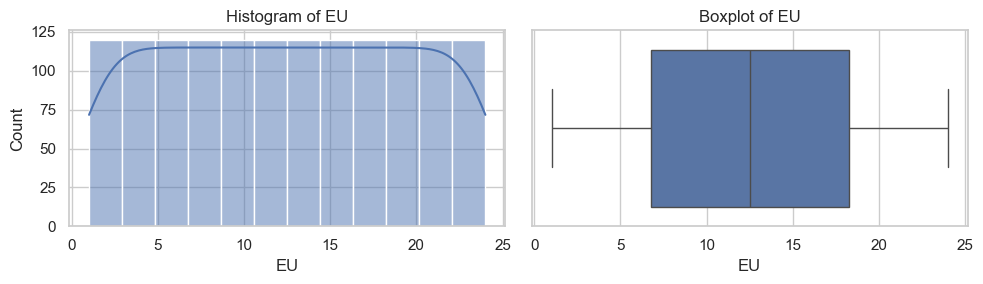

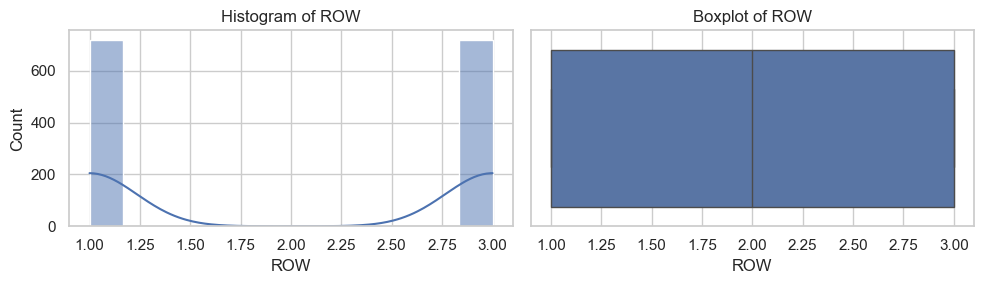

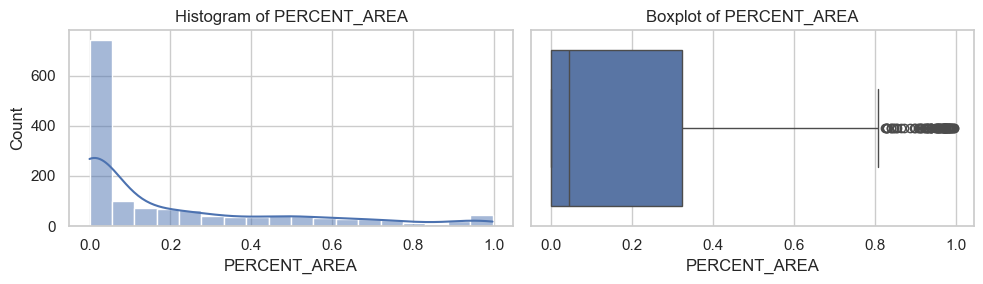

In [11]:
# Distributions of numeric columns

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns:", numeric_cols)

sns.set_theme(style="whitegrid")

for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    sns.histplot(df[col].dropna(), kde=True, ax=axes[0])
    axes[0].set_title(f"Histogram of {col}")

    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f"Boxplot of {col}")

    plt.tight_layout()
    plt.show()

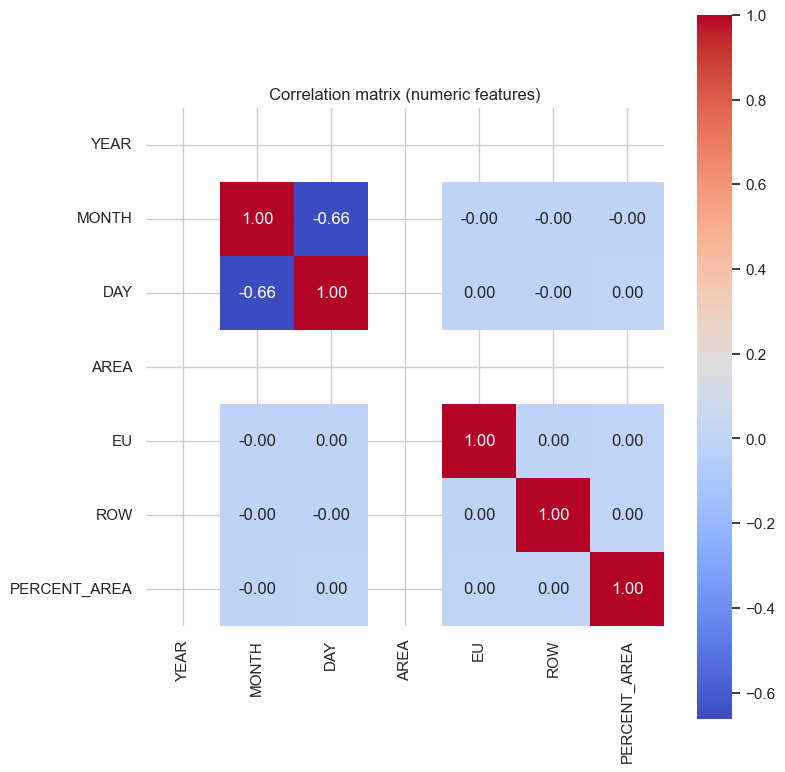

In [12]:
# Correlation matrix for numeric features

if len(numeric_cols) >= 2:
    corr = df[numeric_cols].corr()
    plt.figure(figsize=(min(0.6 * len(numeric_cols) + 4, 14),
                        min(0.6 * len(numeric_cols) + 4, 14)))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
    plt.title("Correlation matrix (numeric features)")
    plt.tight_layout()
else:
    print("Not enough numeric columns for a correlation heatmap.")